# 04 — 第三代：Hybrid Pipeline + Data Recovery

**方法论定位（第三代，Nemotron-CC 2024）**

三个核心创新：
1. **分类器集成（Classifier Ensembling）**：多个分类器取并集，扩大高质量覆盖面
2. **条件性 Heuristic Bypass**：对高质量文档跳过 heuristic，减少误杀（Nemotron-CC 发现误杀率 18.1%）
3. **合成数据改写（Synthetic Rephrasing）**：低质量数据用 LLM API 改写后回收

**与第二代的核心区别**：
- 第二代丢弃 90% 数据（激进过滤）
- 第三代在质量不降的前提下保留约 38% 数据（4倍于第二代）
- Nemotron-CC：8B 模型 15T token 训练后超过 Llama 3.1 8B：MMLU +5, ARC-Challenge +3.1

> **本 notebook 读取预计算的 pipeline 结果进行可视化分析，不执行 pipeline 本身。**

## Cell Group A: 分类器集成（Classifier Ensembling）

> **为什么需要集成？单一分类器的盲区问题**
>
> 无论正样本是 OpenHermes（DCLM 风格）还是 Wikipedia（教育风格），
> 单一分类器都会有覆盖盲区。
> 例如：技术博客可能被“OpenHermes 风格”分类器低估，
> 却被“教育类”分类器高估。
>
> **Union 策略**：任一分类器认为高质量 → 判为高质量
> - 优点：扩大覆盖面，减少漏网之鱼
> - 缺点：可能引入更多噪声（对比 Intersection 策略）
>
> **Intersection 策略**：所有分类器都认为高质量
> - 类似第二代，更保守，质量更高但量更少
>
> Nemotron-CC 使用 Union 策略，实现了 +28% unique token 覆盖。

In [1]:
# === 加载配置和预计算结果 ===
# 读取 run_config、gen3 路由汇总、gen3 输出文档、gen1 输出文档。
# 本 notebook 不执行 pipeline，只读取已有结果进行可视化分析。

import sys, json
sys.path.insert(0, '..')
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
from pathlib import Path
from src.utils.config_loader import load_run_config, print_config_summary

run_cfg = load_run_config()
print_config_summary(run_cfg)

# --- 加载路由汇总 ---
summary_path = Path('../data/gen3_output/gen3_routing_summary.json')
with open(summary_path) as f:
    summary = json.load(f)
print(f'\n已加载路由汇总: {summary_path}')

# --- 加载 Gen3 输出文档 ---
gen3_path = Path('../data/gen3_output/gen3_output.jsonl')
gen3_docs = []
with open(gen3_path) as f:
    for line in f:
        gen3_docs.append(json.loads(line))
print(f'已加载 Gen3 输出: {len(gen3_docs):,} 条')

# --- 加载 Gen1 输出文档（Gen3 的输入） ---
gen1_path = Path('../data/gen1_output/gen1_output.jsonl')
gen1_docs = []
with open(gen1_path) as f:
    for line in f:
        gen1_docs.append(json.loads(line))
print(f'已加载 Gen1 输出 (作为 Gen3 输入): {len(gen1_docs):,} 条')

# --- 提取关键数据 ---
routing = summary['routing']
bypass = summary['bypass_analysis']
rephrase = summary['rephrasing']
total_input = routing['total']

ensemble_scores = np.array([d.get('_ensemble_score', 0) for d in gen3_docs])
synthetic_count = sum(1 for d in gen3_docs if d.get('_synthetic'))

print(f'\n路由汇总:')
print(f'  输入文档: {total_input:,}')
print(f'  最终保留: {routing["total_kept"]:,}')
print(f'  合成文档: {synthetic_count:,}')

  当前运行模式: MEDIUM_RUN
  20-30分钟跑完，产出有统计意义的对比数据
──────────────────────────────────────────────────
  doc_limit       : 12,000
  eval_sample_size: 500
  audit_sample_size: 50
  rewrite_count   : 100
  random_seed     : 42

已加载路由汇总: ../data/gen3_output/gen3_routing_summary.json
已加载 Gen3 输出: 17 条
已加载 Gen1 输出 (作为 Gen3 输入): 409 条

路由汇总:
  输入文档: 409
  最终保留: 17
  合成文档: 0


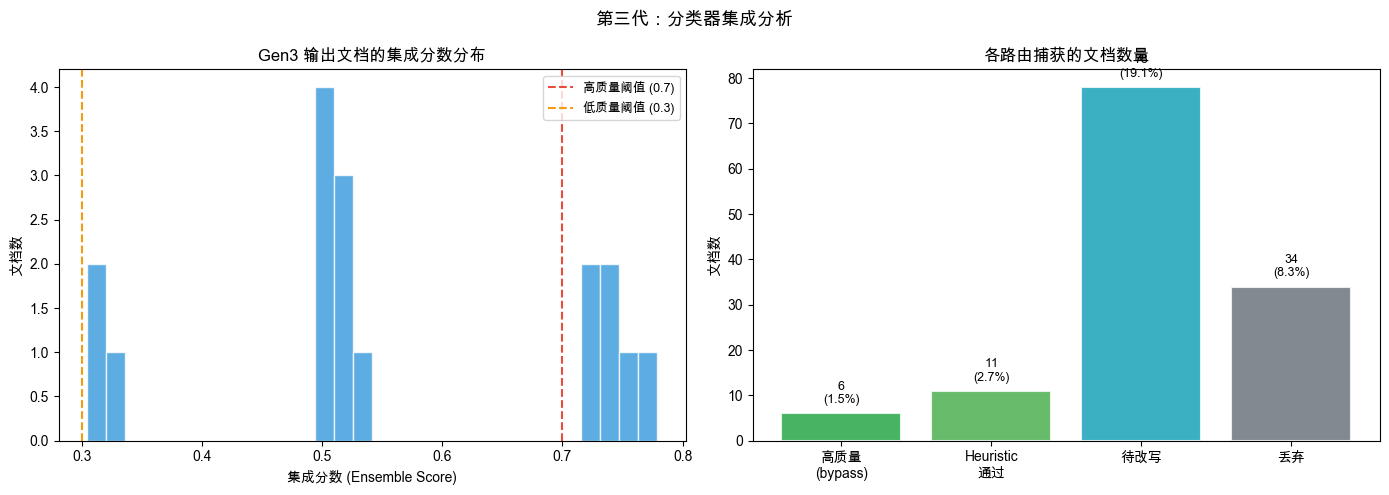

图表已保存: results/figures/04_gen3_ensemble_coverage.png


In [2]:
# === 集成覆盖率可视化 ===
# 左图：Gen3 输出文档的集成分数分布
# 右图：各路由捕获的文档数量对比（柱状图）

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- 左图：集成分数分布 --
axes[0].hist(ensemble_scores, bins=30, color='#3498db', alpha=0.8, edgecolor='white')
axes[0].axvline(x=0.7, color='#e74c3c', linestyle='--', linewidth=1.5, label='高质量阈值 (0.7)')
axes[0].axvline(x=0.3, color='#f39c12', linestyle='--', linewidth=1.5, label='低质量阈值 (0.3)')
axes[0].set_xlabel('集成分数 (Ensemble Score)')
axes[0].set_ylabel('文档数')
axes[0].set_title('Gen3 输出文档的集成分数分布')
axes[0].legend(fontsize=9)

# -- 右图：各路由捕获的文档数量 --
route_names = ['高质量\n(bypass)', 'Heuristic\n通过', '待改写', '丢弃']
route_counts = [
    routing['high_quality']['count'],
    routing['heuristic_passed']['count'],
    routing['to_rephrase']['count'],
    routing['discarded']['count'],
]
route_colors = ['#28a745', '#4CAF50', '#17a2b8', '#6c757d']

bars = axes[1].bar(route_names, route_counts, color=route_colors, alpha=0.85,
                    edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, route_counts):
    pct = count / total_input * 100
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(route_counts) * 0.02,
                 f'{count:,}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('文档数')
axes[1].set_title('各路由捕获的文档数量')

plt.suptitle('第三代：分类器集成分析', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/04_gen3_ensemble_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print('图表已保存: results/figures/04_gen3_ensemble_coverage.png')

## Cell Group B: 条件性 Heuristic Bypass

> **核心问题：Heuristic 会误杀多少高质量文档？**
>
> Nemotron-CC 的关键发现：对 fastText 判定为高质量的文档，
> 如果再应用 heuristic filter，会误杀 **18.1% 的高质量 token**。
>
> **误杀的原因举例**：
> - 代码文档：含大量特殊字符 → 被 Gopher 的“alpha ratio”规则过滤
> - 技术教程：含代码片段（短行）→ 被 C4 的行规则过滤
> - 问答格式文本：平均句子短 → 被 Gopher 的 avg_sentence_length 过滤
>
> **解决方案（Bypass 路由）**：
> - score >= 0.7：直接保留（跳过 heuristic）
> - 0.3 <= score < 0.7：应用 heuristic
> - score < 0.3：送去 LLM 改写或丢弃

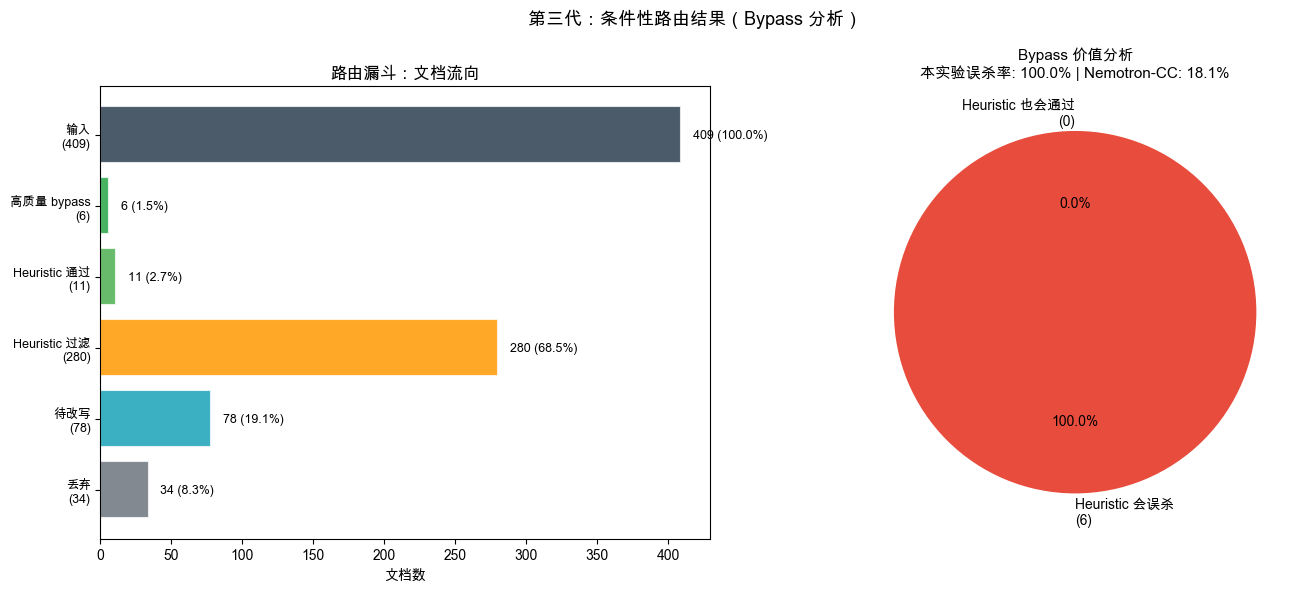

图表已保存: results/figures/04_gen3_routing.png


In [3]:
# === 条件性 Bypass 路由漏斗图 ===
# 可视化路由流程：输入 -> 高质量 bypass -> heuristic -> 改写 -> 丢弃
# 突出 bypass_save_rate（对标 Nemotron-CC 18.1% 发现）

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -- 左图：路由漏斗（横向条形图） --
hq = routing['high_quality']['count']
hp = routing['heuristic_passed']['count']
hf = routing['heuristic_filtered']['count']
tr = routing['to_rephrase']['count']
dc = routing['discarded']['count']

funnel_labels = [
    f'输入\n({total_input:,})',
    f'高质量 bypass\n({hq:,})',
    f'Heuristic 通过\n({hp:,})',
    f'Heuristic 过滤\n({hf:,})',
    f'待改写\n({tr:,})',
    f'丢弃\n({dc:,})',
]
funnel_values = [total_input, hq, hp, hf, tr, dc]
funnel_colors = ['#2c3e50', '#28a745', '#4CAF50', '#FF9800', '#17a2b8', '#6c757d']

y_pos = range(len(funnel_labels))
hbars = axes[0].barh(y_pos, funnel_values, color=funnel_colors, alpha=0.85,
                      edgecolor='white', linewidth=1.5)
axes[0].set_yticks(list(y_pos))
axes[0].set_yticklabels(funnel_labels, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('文档数')
axes[0].set_title('路由漏斗：文档流向', fontweight='bold')
for bar, val in zip(hbars, funnel_values):
    if val > 0:
        axes[0].text(bar.get_width() + max(funnel_values) * 0.02,
                     bar.get_y() + bar.get_height() / 2,
                     f'{val:,} ({val/total_input:.1%})',
                     va='center', fontsize=9)

# -- 右图：Bypass 价值分析 --
hq_count = bypass['high_quality_count']
filtered_count = bypass['would_be_filtered_count']
filtered_rate = bypass['would_be_filtered_rate']
saved_count = hq_count - filtered_count

if hq_count > 0:
    if filtered_count > 0:
        wedge_sizes = [saved_count, filtered_count]
        wedge_labels = [
            f'Heuristic 也会通过\n({saved_count})',
            f'Heuristic 会误杀\n({filtered_count})',
        ]
        wedge_colors = ['#28a745', '#e74c3c']
    else:
        wedge_sizes = [hq_count]
        wedge_labels = [f'Heuristic 也会通过\n({hq_count})']
        wedge_colors = ['#28a745']
    axes[1].pie(wedge_sizes, labels=wedge_labels, colors=wedge_colors,
                autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
else:
    axes[1].text(0.5, 0.5, '无高质量 bypass 文档',
                 ha='center', va='center', fontsize=12, transform=axes[1].transAxes)

title_line2 = f'本实验误杀率: {filtered_rate:.1%} | Nemotron-CC: 18.1%'
axes[1].set_title('Bypass 价值分析\n' + title_line2,
                   fontweight='bold', fontsize=11)

plt.suptitle('第三代：条件性路由结果（Bypass 分析）', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/04_gen3_routing.png', dpi=150, bbox_inches='tight')
plt.show()
print('图表已保存: results/figures/04_gen3_routing.png')

## Cell Group C: 合成数据改写（Synthetic Rephrasing）

> **核心理念：低质量数据不是垃圾，而是待改写的原材料**
>
> Nemotron-CC 的洞见：通过 LLM API 将低质量文本改写为高质量文本，实现数据回收。
>
> **成本效益分析**：
> - Anthropic Haiku：约 $0.0003/千 token（输入）
> - 改写 300 条文档（full_run 配置）≈ 300 x 500 tokens = 150K tokens ≈ **$0.05**
> - 这 300 条变成高质量数据后，价值 >> 成本
>
> **改写后的质量验证**：
> 改写后的文档需要通过评估分类器验证（分数 >= 0.4 才保留），
> 避免“改写失败”（LLM 生成了更差的文本）的情况。

In [4]:
# === 改写统计 ===
# 显示 LLM 改写的尝试/成功/失败统计

print('=' * 50)
print('  合成数据改写 (Synthetic Rephrasing) 统计')
print('=' * 50)

if rephrase.get('skipped', False):
    print('  状态: 已跳过 (未配置 API Key 或无待改写文档)')
    rephrase_candidates = routing['to_rephrase']['count']
    print(f'  待改写候选: {rephrase_candidates:,} 条')
    print()
    print('  提示: 配置 configs/api_config.yaml 中的 api_key 可启用 LLM 改写')
else:
    attempted = rephrase.get('attempted', 0)
    succeeded = rephrase.get('succeeded', 0)
    failed = rephrase.get('failed', 0)
    print(f'  尝试改写: {attempted:,} 条')
    print(f'  成功: {succeeded:,} 条')
    print(f'  失败: {failed:,} 条')
    if attempted > 0:
        print(f'  成功率: {succeeded/attempted:.1%}')
    print(f'  合成文档占最终输出: {synthetic_count:,} / {len(gen3_docs):,}')

print()
elapsed = summary['elapsed_seconds']
print(f'  Pipeline 执行时间: {elapsed:.2f} 秒')

  合成数据改写 (Synthetic Rephrasing) 统计
  状态: 已跳过 (未配置 API Key 或无待改写文档)
  待改写候选: 78 条

  提示: 配置 configs/api_config.yaml 中的 api_key 可启用 LLM 改写

  Pipeline 执行时间: 0.64 秒


In [5]:
# === 第三代最终汇总 + 与第二代对比 ===

total_kept = routing['total_kept']
retention_rate = total_kept / total_input
gen2_approx = int(total_input * 0.10)  # 第二代约保留 top-10%

print('=' * 60)
print('  第三代 Hybrid Pipeline -- 最终结论')
print('=' * 60)
print(f'  输入文档数: {total_input:,}')
print(f'  最终输出: {total_kept:,} 条')
hq_c = routing['high_quality']['count']
hp_c = routing['heuristic_passed']['count']
print(f'  |-- 高质量(bypass): {hq_c:,} 条')
print(f'  |-- 中等(heuristic通过): {hp_c:,} 条')
print(f'  +-- 合成数据(改写): {synthetic_count:,} 条')
print(f'  总保留率: {retention_rate:.1%}')
print()
print('  对比第二代（top-10%）:')
print(f'  第二代输出约: {gen2_approx:,} 条')
print(f'  第三代输出约: {total_kept:,} 条')
if gen2_approx > 0:
    print(f'  数据量倍数: {total_kept/gen2_approx:.1f}x')
print()

# 汇总表格
header_route = '路由'
header_count = '文档数'
header_pct = '占比'
print('路由明细表：')
print(f'{header_route:<20} {header_count:>8} {header_pct:>8}')
print('-' * 38)
for name, key in [('高质量 bypass', 'high_quality'),
                   ('Heuristic 通过', 'heuristic_passed'),
                   ('Heuristic 过滤', 'heuristic_filtered'),
                   ('待改写', 'to_rephrase'),
                   ('丢弃', 'discarded')]:
    c = routing[key]['count']
    r = routing[key]['rate']
    print(f'{name:<20} {c:>8,} {r:>8.1%}')
print('-' * 38)
footer_label = '最终保留'
print(f'{footer_label:<20} {total_kept:>8,} {retention_rate:>8.1%}')
print()
print('  下一步 -> Notebook 05：去重分析')

  第三代 Hybrid Pipeline -- 最终结论
  输入文档数: 409
  最终输出: 17 条
  |-- 高质量(bypass): 6 条
  |-- 中等(heuristic通过): 11 条
  +-- 合成数据(改写): 0 条
  总保留率: 4.2%

  对比第二代（top-10%）:
  第二代输出约: 40 条
  第三代输出约: 17 条
  数据量倍数: 0.4x

路由明细表：
路由                        文档数       占比
--------------------------------------
高质量 bypass                  6     1.5%
Heuristic 通过               11     2.7%
Heuristic 过滤              280    68.5%
待改写                        78    19.1%
丢弃                         34     8.3%
--------------------------------------
最终保留                       17     4.2%

  下一步 -> Notebook 05：去重分析
